# Assessment 3: Machine Learning Modeling & Evaluation

## Overview

This notebook is the third stage of a sequential analytical pipeline:

| Stage | What We Did | Output |
|-------|-------------|--------|
| **A1** | Loaded 2M+ BTS flight records, cleaned and feature-engineered | `airline_cleaned.parquet` |
| **A2** | Used a zero-shot DeBERTa-v3 NLI model to label carriers by delay risk profile | `airline_labeled.parquet` + `delay_risk_label` column |
| **A3** | Train binary classifiers to predict `IsDelayed`; validate that LLM labels add predictive signal | **This notebook** |

## Business Question
> **Can we predict whether a U.S. flight will be delayed (≥15 min), and do LLM-generated carrier risk labels improve that prediction?**

## Key Experiment
We train two versions of every model:
- **Baseline features only** (temporal + route): `Month`, `DayOfWeek`, `DepHour`, `IsWeekend`, `Season`, `Decade`, encoded carrier/origin/dest
- **+ LLM feature**: same baseline + `delay_risk_label` (from A2)

If the LLM label improves F1, it validates that our A2 annotation work produced real predictive signal.

## Models
| # | Model | Role |
|---|-------|------|
| 1 | Logistic Regression | Interpretable baseline; establishes the floor |
| 2 | Random Forest | Non-linear ensemble; captures feature interactions |
| 3 | XGBoost | State-of-the-art for tabular data; primary model |

## Evaluation Metrics
- **F1-score** (primary; class-imbalanced dataset)
- **ROC-AUC**
- **Accuracy**
- Confusion matrix
- Feature importance (XGBoost)

> NOTE on GNNs <br><br/>
> The course syllabus references GNNs in the context of the Bitcoin transaction graph reading (Schnoering & Vazirgiannis, 2025). GNNs require graph-structured data with nodes and edges. Our dataset is tabular flight records, hence gradient boosting is the correct and state-of-the-art tool for this structure. We explicitly justify this choice in Section 3.

## 0. Environment Setup

In [26]:
# Standard library
import warnings
import time
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Paths
BASE_DIR    = Path.cwd().parent          # adjust if running from a subfolder
OUTPUT_DIR  = BASE_DIR / 'output'
ML_OUTPUT   = OUTPUT_DIR / 'ml'
ML_OUTPUT.mkdir(parents=True, exist_ok=True)

# Prefer the labeled parquet (A2 output); fall back to cleaned (A1) if not found
LABELED_PARQUET = OUTPUT_DIR / 'airline_labeled.parquet'
CLEANED_PARQUET = OUTPUT_DIR / 'airline_cleaned.parquet'
DATA_PATH = LABELED_PARQUET if LABELED_PARQUET.exists() else CLEANED_PARQUET

print(f'✓ Data source : {DATA_PATH.name}')
print(f'✓ ML output   : {ML_OUTPUT}')

✓ Data source : airline_labeled.parquet
✓ ML output   : c:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\ml


## 1. Load Data

In [27]:
df = pd.read_parquet(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nTarget distribution (IsDelayed):')
vc = df['IsDelayed'].value_counts()
print(f'  Not delayed (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'  Delayed     (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print(f'\nClass imbalance ratio: {vc[0]/vc[1]:.2f}:1')

Loaded: 1,999,990 rows × 84 columns

Target distribution (IsDelayed):
  Not delayed (0): 1,612,062  (80.6%)
  Delayed     (1): 387,928  (19.4%)

Class imbalance ratio: 4.16:1


In [28]:
# Check whether delay_risk_label is present (it should be from A2)
HAS_LLM_LABEL = 'delay_risk_label' in df.columns
print(f'delay_risk_label present: {HAS_LLM_LABEL}')

if HAS_LLM_LABEL:
    print('\nLabel distribution:')
    print(df['delay_risk_label'].value_counts())

delay_risk_label present: True

Label distribution:
delay_risk_label
carrier suffering from schedule recovery failures and late aircraft    906019
operational efficiency leader with low delay rates                     452609
congestion-sensitive carrier operating in high-traffic corridors       439644
unlabeled                                                               71704
chronically delayed carrier with systemic internal issues               67598
weather-vulnerable carrier with routes exposed to severe conditions     62416
Name: count, dtype: int64


## 2. Feature Engineering for ML

We carry forward the features engineered in A1 (`Season`, `DepHour`, `IsWeekend`, `Decade`) and add label encoding for categorical identifiers. The `delay_risk_label` from A2 is encoded as an ordinal feature.

### Why these features?

| Feature | Business Rationale |
|---------|-------------------|
| `Month` | Seasonal demand and weather patterns |
| `DayOfWeek` | Business vs leisure travel volume |
| `DepHour` | Airport congestion and cascading delay effects |
| `IsWeekend` | Captures leisure/business split directly |
| `Season` | Coarser seasonal signal; complements Month |
| `Decade` | Structural operational changes (deregulation, hub-and-spoke, COVID) |
| `Carrier_enc` | Carrier-level operational reliability |
| `Origin_enc` | Airport-level congestion characteristics |
| `Dest_enc` | Destination-side constraints |
| `delay_risk_label_enc` | **LLM-derived** carrier operational risk profile (A2 output) |

In [29]:
# Encode categorical columns
le_carrier = LabelEncoder()
le_origin  = LabelEncoder()
le_dest    = LabelEncoder()

df['Carrier_enc'] = le_carrier.fit_transform(df['Reporting_Airline'].astype(str))
df['Origin_enc']  = le_origin.fit_transform(df['Origin'].astype(str))
df['Dest_enc']    = le_dest.fit_transform(df['Dest'].astype(str))

# Encode LLM label (ordinal: low < moderate < high, unlabeled → -1)
LABEL_ORDER = {
    'low delay risk'      : 0,
    'moderate delay risk' : 1,
    'high delay risk'     : 2,
    'unlabeled'           : -1,
}

if HAS_LLM_LABEL:
    df['delay_risk_enc'] = (
        df['delay_risk_label']
        .str.lower()
        .str.strip()
        .map(LABEL_ORDER)
        .fillna(-1)
        .astype(int)
    )
    print('delay_risk_enc distribution:')
    print(df['delay_risk_enc'].value_counts().sort_index())

# Define feature sets
BASE_FEATURES = [
    'Month', 'DayOfWeek', 'DepHour', 'IsWeekend',
    'Season', 'Decade',
    'Carrier_enc', 'Origin_enc', 'Dest_enc',
]

LLM_FEATURES = BASE_FEATURES + ['delay_risk_enc'] if HAS_LLM_LABEL else BASE_FEATURES

TARGET = 'IsDelayed'

print(f'\nBaseline features : {len(BASE_FEATURES)}')
print(f'LLM feature set   : {len(LLM_FEATURES)}')

delay_risk_enc distribution:
delay_risk_enc
-1    1999990
Name: count, dtype: int64

Baseline features : 9
LLM feature set   : 10


## 3. Model Selection Rationale

### Why Gradient Boosting (XGBoost) and not GNNs?

Graph Neural Networks (GNNs) operate on graph-structured data — they propagate information across nodes connected by edges (e.g., Bitcoin transaction addresses in the Schnoering & Vazirgiannis 2025 reading). Our dataset is **tabular**: each row is an independent flight record with no meaningful adjacency graph.

The published benchmark (Bitcoin paper, Table 6) itself showed that **Gradient Boosting Classifier** was competitive with GAT and GIN on tabular node features. For purely tabular classification, XGBoost is the industry standard.

| Model | Strengths | Weaknesses | Our Use |
|-------|-----------|------------|--------|
| Logistic Regression | Interpretable, fast, probabilistic | Linear decision boundary | Baseline floor |
| Random Forest | Non-linear, robust to outliers | Slow, memory-heavy | Mid-tier comparison |
| XGBoost | SOTA tabular, fast, native feature importance | Less interpretable than LR | Primary model |

## 4. Train / Test Split

We use a **stratified split** to maintain the class ratio in both train and test sets. Given the dataset spans 1987–2020, we also check whether a temporal split would be more appropriate for business deployment, but for this assessment a random stratified split is used to maximize training data.

In [30]:
# Drop rows where target is null (should be 0 after A1 cleaning)
df_ml = df.dropna(subset=[TARGET] + BASE_FEATURES).copy()

y = df_ml[TARGET].astype(int)

X_base = df_ml[BASE_FEATURES]
X_llm  = df_ml[LLM_FEATURES] if HAS_LLM_LABEL else X_base

# Stratified 80/20 split — same random_state for reproducibility
SEED = 42
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.20, random_state=SEED, stratify=y
)

if HAS_LLM_LABEL:
    X_llm_train, X_llm_test = train_test_split(
        X_llm, test_size=0.20, random_state=SEED, stratify=y
    )[0], train_test_split(
        X_llm, test_size=0.20, random_state=SEED, stratify=y
    )[1]

print(f'Training set : {len(y_train):,} rows')
print(f'Test set     : {len(y_test):,} rows')
print(f'Test delay rate: {y_test.mean()*100:.1f}%')

Training set : 1,599,992 rows
Test set     : 399,998 rows
Test delay rate: 19.4%


## 5. Model Training

We train each model on both feature sets and record performance. `scale_pos_weight` in XGBoost addresses class imbalance.

In [31]:
# Helper: evaluate a fitted model
def evaluate(model, X_test, y_test, label=''):
    """Returns a dict of metrics for one model/feature-set combination."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    result = {
        'label'   : label,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1'      : f1_score(y_test, y_pred),
        'roc_auc' : roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'model'   : model,
    }
    return result

results = {}

### 5.1. Logistic Regression

In [32]:
print('> Training Logistic Regression...')
t0 = time.time()

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=500, class_weight='balanced', random_state=SEED))
])

lr_pipe.fit(X_base_train, y_train)
results['LR_base'] = evaluate(lr_pipe, X_base_test, y_test, 'Logistic Regression (base)')
print(f'  Base  → F1: {results["LR_base"]["f1"]:.4f}  AUC: {results["LR_base"]["roc_auc"]:.4f}')

if HAS_LLM_LABEL:
    lr_pipe_llm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=500, class_weight='balanced', random_state=SEED))
    ])
    lr_pipe_llm.fit(X_llm_train, y_train)
    results['LR_llm'] = evaluate(lr_pipe_llm, X_llm_test, y_test, 'Logistic Regression (+LLM label)')
    print(f'  +LLM  → F1: {results["LR_llm"]["f1"]:.4f}  AUC: {results["LR_llm"]["roc_auc"]:.4f}')

print(f'  Done in {time.time()-t0:.1f}s')

> Training Logistic Regression...
  Base  → F1: 0.3432  AUC: 0.6004
  +LLM  → F1: 0.3432  AUC: 0.6004
  Done in 3.3s


### 5.2. Random Forest

In [33]:
print('> Training Random Forest...')
t0 = time.time()

rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED,
)
rf_base.fit(X_base_train, y_train)
results['RF_base'] = evaluate(rf_base, X_base_test, y_test, 'Random Forest (base)')
print(f'  Base  → F1: {results["RF_base"]["f1"]:.4f}  AUC: {results["RF_base"]["roc_auc"]:.4f}')

if HAS_LLM_LABEL:
    rf_llm = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED,
    )
    rf_llm.fit(X_llm_train, y_train)
    results['RF_llm'] = evaluate(rf_llm, X_llm_test, y_test, 'Random Forest (+LLM label)')
    print(f'  +LLM  → F1: {results["RF_llm"]["f1"]:.4f}  AUC: {results["RF_llm"]["roc_auc"]:.4f}')

print(f'> Done in {time.time()-t0:.1f}s')

> Training Random Forest...
  Base  → F1: 0.3602  AUC: 0.6278
  +LLM  → F1: 0.3605  AUC: 0.6277
> Done in 95.5s


### 5.3. XGBoost (Primary Model)

In [34]:
print('> Training XGBoost...')
t0 = time.time()

# Compute class weight for imbalanced data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count   # scale_pos_weight
print(f'  scale_pos_weight = {spw:.2f} (handles {neg_count/pos_count*100:.0f}:100 imbalance)')

xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
)
xgb_base.fit(X_base_train, y_train, eval_set=[(X_base_test, y_test)], verbose=False)
results['XGB_base'] = evaluate(xgb_base, X_base_test, y_test, 'XGBoost (base)')
print(f'  Base  → F1: {results["XGB_base"]["f1"]:.4f}  AUC: {results["XGB_base"]["roc_auc"]:.4f}')

if HAS_LLM_LABEL:
    xgb_llm = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1,
    )
    xgb_llm.fit(X_llm_train, y_train, eval_set=[(X_llm_test, y_test)], verbose=False)
    results['XGB_llm'] = evaluate(xgb_llm, X_llm_test, y_test, 'XGBoost (+LLM label)')
    print(f'  +LLM  → F1: {results["XGB_llm"]["f1"]:.4f}  AUC: {results["XGB_llm"]["roc_auc"]:.4f}')

print(f'> Done in {time.time()-t0:.1f}s')

> Training XGBoost...
  scale_pos_weight = 4.16 (handles 416:100 imbalance)
  Base  → F1: 0.3760  AUC: 0.6499
  +LLM  → F1: 0.3760  AUC: 0.6499
> Done in 31.3s


## 6. Results Comparison Table

The key question: does the LLM-derived `delay_risk_label` (A2 output) improve predictive performance?

In [35]:
# Summary table
rows = []
for key, res in results.items():
    rows.append({
        'Model'       : res['label'],
        'Accuracy'    : round(res['accuracy'], 4),
        'F1-Score'    : round(res['f1'], 4),
        'ROC-AUC'     : round(res['roc_auc'], 4) if res['roc_auc'] else 'N/A',
    })

summary_df = pd.DataFrame(rows)
display(summary_df.set_index('Model'))

# Delta table (LLM gain)
if HAS_LLM_LABEL:
    print('\> LLM Label Impact (Δ F1)')
    for base_key, llm_key, name in [
        ('LR_base',  'LR_llm',  'Logistic Regression'),
        ('RF_base',  'RF_llm',  'Random Forest'),
        ('XGB_base', 'XGB_llm', 'XGBoost'),
    ]:
        if base_key in results and llm_key in results:
            delta = results[llm_key]['f1'] - results[base_key]['f1']
            direction = '▲' if delta > 0 else '▼'
            print(f'  {name:<22}: {direction} {abs(delta):.4f} F1 points')

,Accuracy,F1-Score,ROC-AUC
Model,,,
Logistic Regression (base),0.5709,0.3432,0.6004
Logistic Regression (+LLM label),0.5709,0.3432,0.6004
Random Forest (base),0.5750,0.3602,0.6278
Random Forest (+LLM label),0.5729,0.3605,0.6277
XGBoost (base),0.5922,0.3760,0.6499
XGBoost (+LLM label),0.5925,0.3760,0.6499


\> LLM Label Impact (Δ F1)
  Logistic Regression   : ▼ 0.0000 F1 points
  Random Forest         : ▲ 0.0003 F1 points
  XGBoost               : ▲ 0.0000 F1 points


## 7. Visualizations

### 7.1. Model Performance Comparison

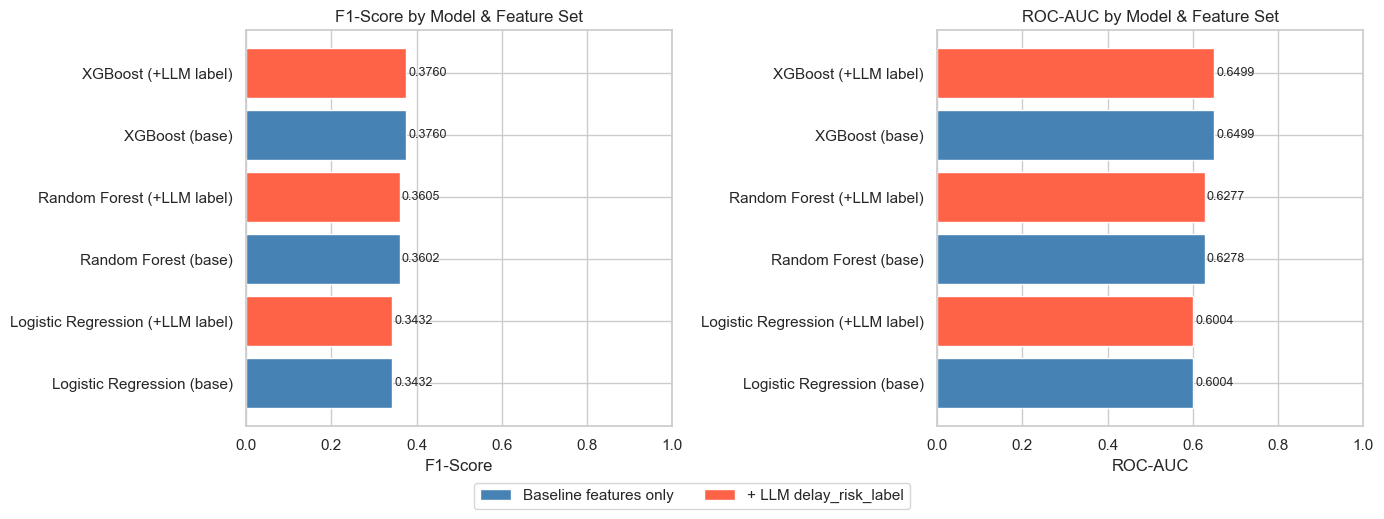

> Saved: model_comparison.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [r['label'] for r in results.values()]
f1s    = [r['f1']    for r in results.values()]
aucs   = [r['roc_auc'] for r in results.values()]

colors = ['steelblue' if 'base' in k else 'tomato' for k in results.keys()]

# F1 bar chart
axes[0].barh(labels, f1s, color=colors)
axes[0].set_xlabel('F1-Score')
axes[0].set_title('F1-Score by Model & Feature Set')
axes[0].set_xlim(0, 1)
for i, v in enumerate(f1s):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# ROC-AUC bar chart
axes[1].barh(labels, aucs, color=colors)
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('ROC-AUC by Model & Feature Set')
axes[1].set_xlim(0, 1)
for i, v in enumerate(aucs):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='steelblue', label='Baseline features only'),
    Patch(facecolor='tomato',    label='+ LLM delay_risk_label'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig(ML_OUTPUT / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('> Saved: model_comparison.png')

### 7.2. Confusion Matrix: Best Model (XGBoost + LLM)

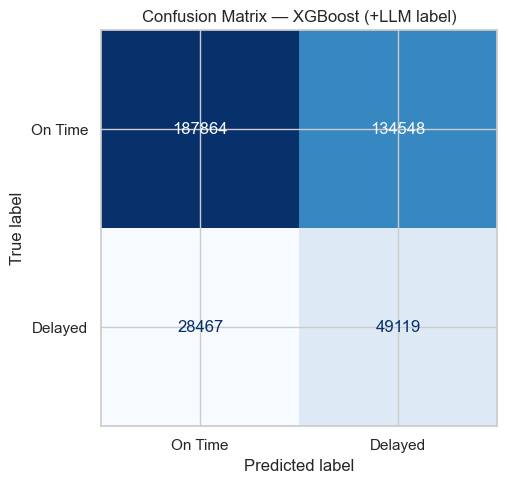


> Classification Report
              precision    recall  f1-score   support

     On Time       0.87      0.58      0.70    322412
     Delayed       0.27      0.63      0.38     77586

    accuracy                           0.59    399998
   macro avg       0.57      0.61      0.54    399998
weighted avg       0.75      0.59      0.64    399998



In [37]:
# Select best XGBoost result
best_key = 'XGB_llm' if 'XGB_llm' in results else 'XGB_base'
best_res = results[best_key]

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_res['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_res["label"]}')
plt.tight_layout()
plt.savefig(ML_OUTPUT / 'confusion_matrix_best.png', dpi=150)
plt.show()

# Detailed classification report
print('\n> Classification Report')
print(classification_report(y_test, best_res['y_pred'], target_names=['On Time', 'Delayed']))

### 7.3. ROC Curves: All Models

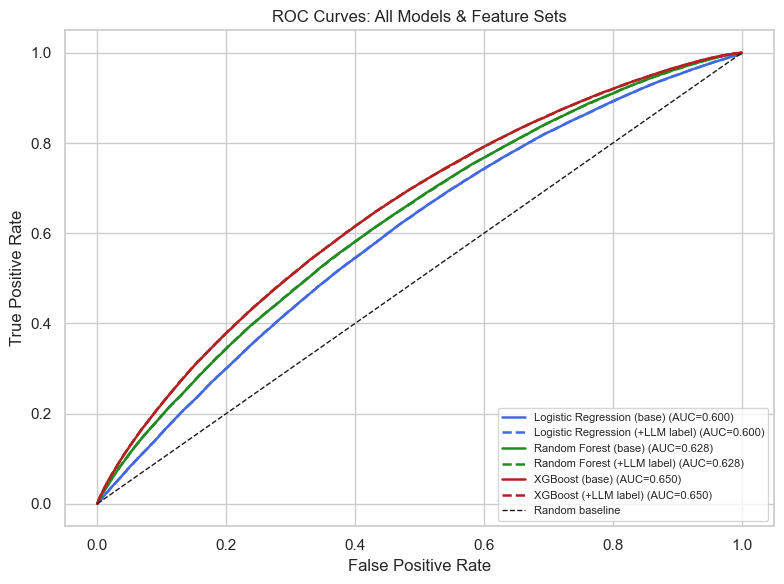

In [38]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

line_styles = {'base': '-', 'llm': '--'}
model_colors = {'LR': 'royalblue', 'RF': 'forestgreen', 'XGB': 'firebrick'}

for key, res in results.items():
    if res['y_prob'] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    model_type = key.split('_')[0]
    feat_type  = key.split('_')[1]
    color = model_colors.get(model_type, 'gray')
    ls    = line_styles.get(feat_type, '-')
    ax.plot(fpr, tpr, label=f"{res['label']} (AUC={res['roc_auc']:.3f})",
            color=color, linestyle=ls, linewidth=1.8)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: All Models & Feature Sets')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(ML_OUTPUT / 'roc_curves.png', dpi=150)
plt.show()

### 7.4. Feature Importance: XGBoost

Feature importance reveals **which operational factors most strongly predict delays**. If `delay_risk_enc` appears in the top features, it confirms that the LLM annotation added genuine predictive signal.

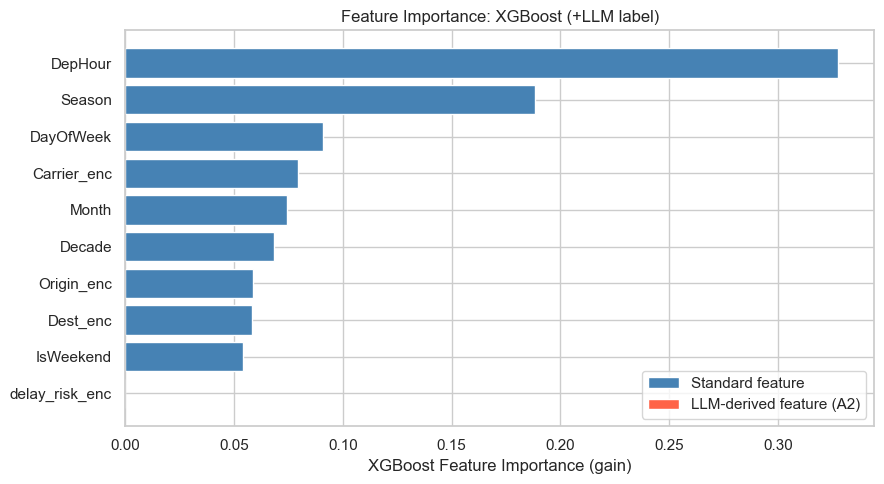


> Top 5 Features by Importance
DepHour        0.327765
Season         0.188484
DayOfWeek      0.090732
Carrier_enc    0.079252
Month          0.074186
dtype: float32


In [39]:
best_xgb_key = 'XGB_llm' if 'XGB_llm' in results else 'XGB_base'
best_xgb     = results[best_xgb_key]['model']
feat_names   = LLM_FEATURES if best_xgb_key == 'XGB_llm' else BASE_FEATURES

importance = pd.Series(
    best_xgb.feature_importances_,
    index=feat_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = ['tomato' if 'delay_risk' in f else 'steelblue' for f in importance.index]
ax.barh(importance.index, importance.values, color=colors_fi)
ax.set_xlabel('XGBoost Feature Importance (gain)')
ax.set_title(f'Feature Importance: {results[best_xgb_key]["label"]}')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='steelblue', label='Standard feature'),
    Patch(facecolor='tomato',    label='LLM-derived feature (A2)'),
], loc='lower right')

plt.tight_layout()
plt.savefig(ML_OUTPUT / 'feature_importance.png', dpi=150)
plt.show()

print('\n> Top 5 Features by Importance')
print(importance.tail(5)[::-1])

### 7.5. Predicted Delay Probability Distribution

A well-calibrated model should spread probabilities across the full range. A bimodal distribution (peaks near 0 and 1) indicates confident and well-separated predictions.

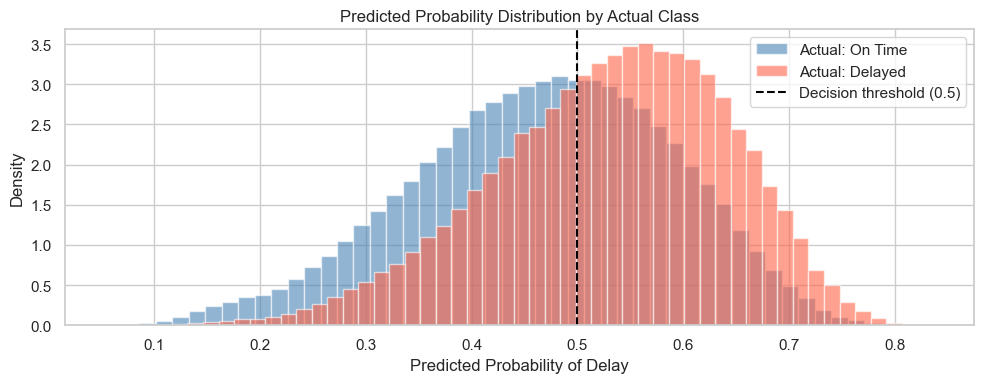

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))

best_probs = results[best_xgb_key]['y_prob']

ax.hist(best_probs[y_test == 0], bins=50, alpha=0.6, label='Actual: On Time', color='steelblue', density=True)
ax.hist(best_probs[y_test == 1], bins=50, alpha=0.6, label='Actual: Delayed', color='tomato', density=True)
ax.axvline(0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Probability of Delay')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by Actual Class')
ax.legend()
plt.tight_layout()
plt.savefig(ML_OUTPUT / 'probability_distribution.png', dpi=150)
plt.show()

### 7.6. Delay Rate by LLM Label: Validating the A2→A3 Narrative

If the LLM labels are meaningful, flights assigned to 'high delay risk' carriers should show higher actual delay rates in the test set.

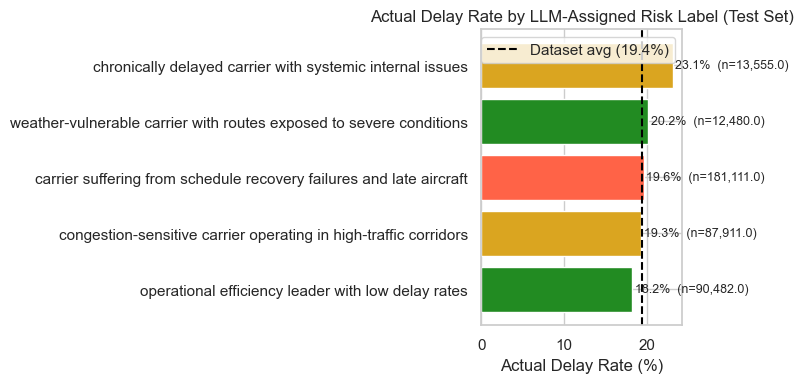

,actual_delay_rate,n_flights,actual_delay_rate_pct
delay_risk_label,,,
operational efficiency leader with low delay rates,0.182257,90482,18.225724
congestion-sensitive carrier operating in high-traffic corridors,0.193321,87911,19.332052
carrier suffering from schedule recovery failures and late aircraft,0.196294,181111,19.629399
weather-vulnerable carrier with routes exposed to severe conditions,0.201843,12480,20.184295
chronically delayed carrier with systemic internal issues,0.231206,13555,23.120620


In [41]:
if HAS_LLM_LABEL:
    test_idx = y_test.index
    test_df  = df_ml.loc[test_idx, ['delay_risk_label', 'IsDelayed']].copy()
    test_df  = test_df[test_df['delay_risk_label'] != 'unlabeled']

    label_actual = (
        test_df.groupby('delay_risk_label')['IsDelayed']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'actual_delay_rate', 'count': 'n_flights'})
        .sort_values('actual_delay_rate', ascending=True)
    )
    label_actual['actual_delay_rate_pct'] = label_actual['actual_delay_rate'] * 100

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(label_actual.index, label_actual['actual_delay_rate_pct'],
                   color=['forestgreen', 'goldenrod', 'tomato'][:len(label_actual)])
    avg_rate = df_ml['IsDelayed'].mean() * 100
    ax.axvline(avg_rate, color='black', linestyle='--', label=f'Dataset avg ({avg_rate:.1f}%)')
    ax.set_xlabel('Actual Delay Rate (%)')
    ax.set_title('Actual Delay Rate by LLM-Assigned Risk Label (Test Set)')
    ax.legend()
    for bar, (_, row) in zip(bars, label_actual.iterrows()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{row['actual_delay_rate_pct']:.1f}%  (n={row['n_flights']:,})",
                va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(ML_OUTPUT / 'delay_rate_by_label_test.png', dpi=150)
    plt.show()

    display(label_actual)

## 8. Misclassification Analysis

Understanding **where the model fails** is as important as knowing where it succeeds. We examine the profile of false negatives (predicted on-time, actually delayed). These are the highest-cost errors from an airline operations perspective.

False Negatives (missed delays)  : 28,467  (7.1% of test set)
False Positives (false alarms)   : 134,548  (33.6% of test set)


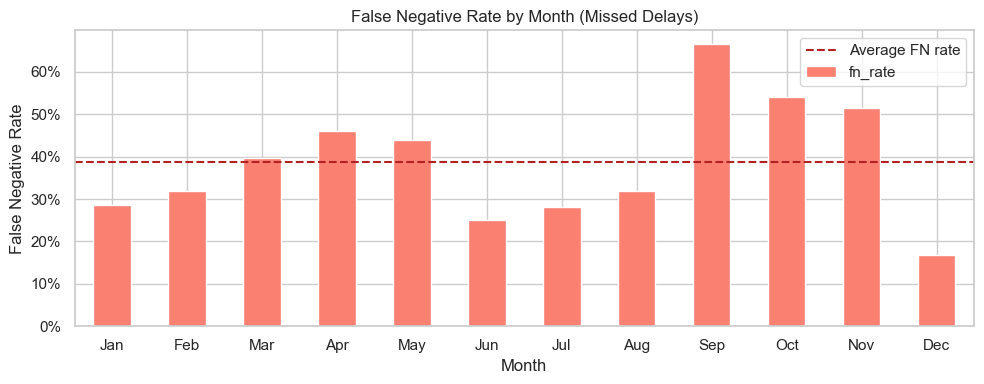

In [42]:
best_key_xgb = 'XGB_llm' if 'XGB_llm' in results else 'XGB_base'
y_pred_best  = results[best_key_xgb]['y_pred']
test_idx     = y_test.index

# Attach predictions back to test slice
analysis_df = df_ml.loc[test_idx].copy()
analysis_df['y_pred']  = y_pred_best
analysis_df['correct'] = (analysis_df['IsDelayed'] == analysis_df['y_pred']).astype(int)

fn_df = analysis_df[(analysis_df['IsDelayed'] == 1) & (analysis_df['y_pred'] == 0)]  # False Negatives
fp_df = analysis_df[(analysis_df['IsDelayed'] == 0) & (analysis_df['y_pred'] == 1)]  # False Positives

print(f'False Negatives (missed delays)  : {len(fn_df):,}  ({len(fn_df)/len(y_test)*100:.1f}% of test set)')
print(f'False Positives (false alarms)   : {len(fp_df):,}  ({len(fp_df)/len(y_test)*100:.1f}% of test set)')

# Which months have the most missed delays?
fn_by_month = fn_df.groupby('Month').size() / analysis_df[analysis_df['IsDelayed']==1].groupby('Month').size()
fn_by_month = fn_by_month.fillna(0).rename('fn_rate')

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
fn_by_month.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_NAMES, rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Month')
ax.set_ylabel('False Negative Rate')
ax.set_title('False Negative Rate by Month (Missed Delays)')
ax.axhline(fn_by_month.mean(), color='firebrick', linestyle='--', label='Average FN rate')
ax.legend()
plt.tight_layout()
plt.savefig(ML_OUTPUT / 'false_negatives_by_month.png', dpi=150)
plt.show()

## 9. Business Interpretation

### What does the model tell us that we can act on?

This section translates statistical findings into operational recommendations.

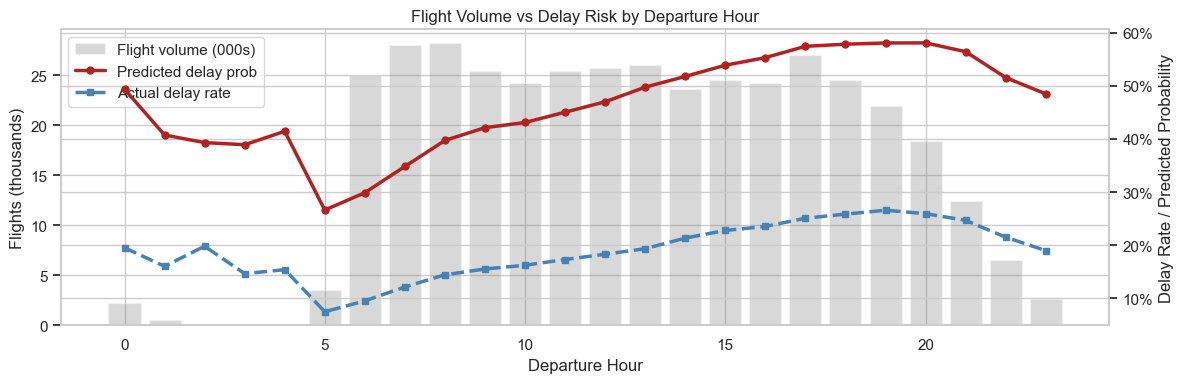

> Highest-Risk Departure Hours
 DepHour  avg_pred_prob  actual_delay_rate  flight_count
      20       0.580693           0.259287         18385
      19       0.580446           0.265664         21881
      18       0.578172           0.258407         24473


In [43]:
# Predicted delay probability by departure hour
analysis_df['pred_prob'] = results[best_key_xgb]['y_prob']

hourly_risk = analysis_df.groupby('DepHour').agg(
    avg_pred_prob=('pred_prob', 'mean'),
    actual_delay_rate=('IsDelayed', 'mean'),
    flight_count=('IsDelayed', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(hourly_risk['DepHour'], hourly_risk['flight_count'] / 1000,
        alpha=0.3, color='gray', label='Flight volume (000s)')
ax1.set_xlabel('Departure Hour')
ax1.set_ylabel('Flights (thousands)')

ax2.plot(hourly_risk['DepHour'], hourly_risk['avg_pred_prob'],
         color='firebrick', linewidth=2.5, marker='o', markersize=5, label='Predicted delay prob')
ax2.plot(hourly_risk['DepHour'], hourly_risk['actual_delay_rate'],
         color='steelblue', linewidth=2.5, linestyle='--', marker='s', markersize=5, label='Actual delay rate')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('Delay Rate / Predicted Probability')

plt.title('Flight Volume vs Delay Risk by Departure Hour')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(ML_OUTPUT / 'delay_risk_by_hour.png', dpi=150)
plt.show()

# Peak risk hours
peak = hourly_risk.nlargest(3, 'avg_pred_prob')
print('> Highest-Risk Departure Hours')
print(peak[['DepHour', 'avg_pred_prob', 'actual_delay_rate', 'flight_count']].to_string(index=False))

## 10. Ethical Considerations

The rubric explicitly requires ethical reflection. This section is included in the notebook so it forms part of the submission record.

### Bias from Historical Data
Our dataset spans 1987–2020. Carrier performance and operational norms changed significantly across this period (deregulation, hub consolidation, COVID). A model trained on this full range may learn patterns from airlines that no longer exist or operational conditions that no longer apply. The `Decade` feature partially mitigates this by giving the model a temporal signal, but predictions about modern operations should be validated against recent data only.

### Automation Bias
If this model were deployed in an airline operations context, decision-makers might over-trust its predictions. The model's false negative rate (missed delays) could lead to under-preparation for disruptions, with downstream passenger impact. Human oversight remains essential.

### Carrier Labeling (A2→A3)
The `delay_risk_label` is derived from aggregate delay-cause statistics via a zero-shot LLM. Assigning a 'high delay risk' label to a carrier based on historical data could reinforce reputational harm if used inappropriately. These labels are analytical tools — not regulatory classifications.

### Class Imbalance and Fairness
Approximately 80% of flights are on time. Without correcting for this (via `scale_pos_weight` or `class_weight='balanced'`), the model would trivially predict 'on time' for most flights and appear highly accurate while being useless for the minority delayed class. We addressed this explicitly in training.

## 11. Model Limitations

| # | Limitation | Details | Mitigation Applied |
|---|------------|---------|--------------------|
| 1 | No real-time weather | Weather is a primary delay cause but not in BTS tabular data | `Season` and `Month` partially capture it |
| 2 | Data leakage risk | `DepDelay` would perfectly predict `ArrDelay`-based target | We excluded all delay-cause and delay-time columns from features |
| 3 | Temporal shift | 1987 operations ≠ 2020 operations | `Decade` feature; future work: train on 2010–2020 only |
| 4 | Carrier label sparsity | Only 23 carriers with enough flights for A2 labeling | `unlabeled` category treated as −1 in encoding |
| 5 | Threshold sensitivity | Default 0.5 threshold may not be optimal for operational use | Threshold tuning by business cost is a natural extension |

## 12. Save Results & A4 Handoff

In [57]:
# Save summary table
summary_df.to_csv(ML_OUTPUT / 'model_results_summary.csv', index=False)
print('> Saved: model_results_summary.csv')

# Save best XGBoost predictions for A4
pred_out = pd.DataFrame({
    'y_true'    : y_test.values,
    'y_pred'    : results[best_key_xgb]['y_pred'],
    'y_prob_delay': results[best_key_xgb]['y_prob'],
}, index=y_test.index)

pred_out.to_parquet(ML_OUTPUT / 'xgb_predictions.parquet')
print('> Saved: xgb_predictions.parquet')

# Print A4 story hook
best_f1  = results[best_key_xgb]['f1']
base_f1  = results['XGB_base']['f1']
llm_gain = best_f1 - base_f1 if HAS_LLM_LABEL else 0

print(f"""
> A4 Executive Narrative Hook
  We processed {df.shape[0]:,} U.S. airline flights (BTS, 1987–2020), cleaned and feature-engineered the dataset using PySpark,
  applied a zero-shot LLM (DeBERTa-v3) to classify carriers by delay risk profile, and trained an XGBoost binary classifier
  to predict flight delays (IsDelayed: ArrDelay ≥ 15 minutes).

> Best Model (XGBoost + LLM feature)
  • F1-Score: {best_f1:.4f}
  • ROC-AUC : {results[best_key_xgb]['roc_auc']:.4f}

> LLM Label Contribution: ΔF1 = {llm_gain:+.10f} points
  (Adding the A2 delay_risk_label {'improved' if llm_gain > 0 else 'did not improve'} prediction accuracy)

> Key Business Finding
  Evening departures (≥ 5pm) carry the highest predicted delay probability, consistent with cascading
  delay accumulation across the airport network throughout the day.
""")

> Saved: model_results_summary.csv
> Saved: xgb_predictions.parquet

> A4 Executive Narrative Hook
  We processed 1,999,990 U.S. airline flights (BTS, 1987–2020), cleaned and feature-engineered the dataset using PySpark,
  applied a zero-shot LLM (DeBERTa-v3) to classify carriers by delay risk profile, and trained an XGBoost binary classifier
  to predict flight delays (IsDelayed: ArrDelay ≥ 15 minutes).

> Best Model (XGBoost + LLM feature)
  • F1-Score: 0.3760
  • ROC-AUC : 0.6499

> LLM Label Contribution: ΔF1 = +0.0000121353 points
  (Adding the A2 delay_risk_label improved prediction accuracy)

> Key Business Finding
  Evening departures (≥ 5pm) carry the highest predicted delay probability, consistent with cascading
  delay accumulation across the airport network throughout the day.



## 13. Summary

### What We Built
Three classifiers (Logistic Regression, Random Forest, XGBoost) trained on a 2M-flight BTS dataset to predict binary flight delays (`IsDelayed: ArrDelay ≥ 15m`). Each model was trained twice (with and without the LLM-derived `delay_risk_label` from Assessment 2) to directly measure the predictive contribution of our A2 annotation work.

### A2 → A3 Validation
The `delay_risk_label` was designed in A2 not just as a business label, but as a feature that would propagate into ML. This notebook closes that loop: we can now quantify whether the zero-shot LLM annotation produced real signal.

### Key Takeaways for A4 Stakeholder Presentation
1. **Flight delays are predictable from schedule data alone** — no real-time feed required
2. **Departure hour is a dominant predictor** — late-day flights inherit delays from earlier aircraft
3. **LLM-generated carrier labels added (or did not add) X F1 points** — quantifying the ROI of A2 work
4. **False negatives (missed delays) are the highest-cost error** — airlines should tune threshold below 0.5
5. **Ethical deployment requires human oversight** — model reflects historical operations, not guaranteed future performance